In [1]:
from fpl_project.scripts.data_utils.visuals import *
from fpl_project.scripts.data_utils.colors_config import team_colors
from fpl_project.scripts.data_utils.features_processing import sort_data
from fpl_project.scripts.model_utils.data import *
from fpl_project.scripts import config

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from scipy import stats
import umap

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests


import warnings
warnings.filterwarnings('ignore')

C:\Users\russ\PycharmProjects\FPL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
pio.renderers.default = "png"


from adjustText import adjust_text



In [4]:
data = pd.read_parquet(config.FPL_HISTORICAL_PATH).dropna(how="any", axis=1)

In [5]:
data.shape

(106188, 43)

In [6]:
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code
0,Nathan Redmond,MID,Southampton,1.5,0,0,3,0,0.0,403,0.0,0.0,0.0,0.0,8,0,0,0.0,0.0,2022-08-06T14:00:00,1,18,0,0,0,0,1,0,0.000050,0,1,4,0.0,1,0,0,0,5.5,False,0,2223,1,83283
1,Junior Stanislas,MID,Bournemouth,1.1,0,0,3,0,0.0,58,0.0,0.0,0.0,0.0,2,0,0,0.0,0.0,2022-08-06T14:00:00,1,2,0,0,0,0,1,0,0.000081,0,0,2,0.0,1,0,0,0,5.0,True,0,2223,1,56872
2,Armando Broja,FWD,Chelsea,2.0,0,0,3,0,0.3,150,0.0,0.0,0.0,0.0,3,0,0,2.5,5.2,2022-08-06T16:30:00,15,8,0,0,0,0,1,0,0.001066,0,1,0,19.0,1,0,0,0,5.5,False,0,2223,1,440323
3,Fabian Schär,DEF,Newcastle,2.4,0,3,43,1,14.6,366,0.0,0.0,0.0,0.0,7,0,1,10.6,66.0,2022-08-06T14:00:00,90,16,0,0,0,0,1,0,0.000342,0,0,2,25.0,15,0,0,0,4.5,True,0,2223,1,119471
4,Jonny Evans,DEF,Leicester,1.9,0,0,15,0,1.3,249,0.0,0.0,0.0,0.0,6,2,0,1.5,14.0,2022-08-07T13:00:00,90,4,0,0,0,0,1,0,0.000207,0,2,2,0.0,1,0,0,0,4.5,True,0,2223,1,37642


In [7]:
data.season.unique()

array(['2223', '2324', '2425', '2526'], dtype=object)

In [8]:
data.team.unique()

array(['Southampton', 'Bournemouth', 'Chelsea', 'Newcastle', 'Leicester',
       "Nott'm Forest", 'Crystal Palace', 'Wolves', 'Brentford', 'Spurs',
       'West Ham', 'Liverpool', 'Leeds', 'Fulham', 'Brighton', 'Man City',
       'Man Utd', 'Everton', 'Arsenal', 'Aston Villa', 'Sheffield Utd',
       'Burnley', 'Luton', 'Ipswich', 'Sunderland'], dtype=object)

In [9]:
data.shape

(106188, 43)

In [10]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float32)
    df["season"] = df["season"].astype(int)

    return df

In [11]:
data.rename(columns={
    "expected_goals_conceded" : "xg_conceded",
    "expected_goals" : "xg",
    "expected_goal_involvements" : "xg_involvements",
    "team_expected_points" : "team_xp",
    "opp_expected_points" : "opp_xp",
    "expected_assists" : "xa"
}, inplace=True)

In [12]:
def exp_per_90(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.reset_index(drop=True)

    minutes = pd.to_numeric(df['minutes'], errors='coerce').replace(0, np.nan)

    for col in x_cols:
        new_col = f"{col}_per_90"

        num_col = pd.to_numeric(df[col], errors='coerce')

        result = num_col / (minutes / 90.0)

        result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[new_col] = result.astype(float)

    return df

In [13]:
def convertion_stats(df:pd.DataFrame)->pd.DataFrame:
    pass

In [14]:
data = numpy_dtypes(data)

data = exp_per_90(data, [c for c in data.columns if "x" in c and c != "ict_index" and c != "xP"])


In [15]:
data.shape

(106188, 48)

In [16]:
data = data.loc[data.position != "AM", :]

In [17]:
data = sort_data(data)
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90,fixture_per_90
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00,0.0,7.0,0.0,0.0,0.0,0.0,32.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,2223,32.0,11948.0,0.0,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,322.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00,0.0,15.0,0.0,0.0,0.0,0.0,33.0,0.0,1.932986e-07,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,2223,33.0,11948.0,0.0,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,337.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00,0.0,10.0,0.0,0.0,0.0,0.0,34.0,0.0,3.452826e-07,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,2223,34.0,11948.0,0.0,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,342.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00,0.0,5.0,0.0,0.0,0.0,0.0,35.0,0.0,6.484797e-07,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,2223,35.0,11948.0,0.0,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,356.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00,0.0,13.0,0.0,0.0,0.0,0.0,36.0,0.0,6.562414e-07,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,2223,36.0,11948.0,0.0,0.0,0.0,0.0,0.0


In [18]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90,fixture_per_90
count,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.00000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000,105866.00000,105866.000000,1.058660e+05,1.058660e+05,1.058660e+05,105866.000000,105866.000000,105866.000000,105866.000000,105866.00000,105866.000000,105866.000000,105866.000000,105866.000000,105866.000000
mean,0.962304,0.034978,0.086156,4.803856,0.075766,4.044899,373.351257,0.022801,0.05837,0.036307,0.395762,188.415634,0.441813,0.038662,1.387412,6.015410,26.632914,10.497469,0.001540,0.000595,0.000463,0.001662,19.551140,0.081726,0.001340,0.269133,1.355279,1.627794,3.82475,1.139573,1.098114e+03,1.536787e+04,1.426969e+04,4.895318,0.052897,2367.393384,19.551140,298436.50000,0.041076,0.109408,0.069597,0.683836,387.540369
std,1.828746,0.198551,0.440297,9.138388,0.264624,9.968705,218.632767,0.077587,0.17451,0.138124,0.734048,106.166786,0.915378,0.213924,2.687025,12.004086,37.923996,5.769852,0.039925,0.024772,0.021944,0.040740,10.642914,0.585817,0.004076,0.443511,1.202389,1.317000,10.49182,2.332077,7.923346e+04,6.659802e+04,5.923703e+04,1.066902,0.223829,109.158342,10.642914,176467.40625,0.385317,0.769756,0.636832,2.342495,2095.369908
min,-3.000000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,-5.000000,-2.993262e+06,0.000000e+00,0.000000e+00,3.600000,0.000000,2223.000000,1.000000,11948.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,185.000000,0.000000,0.00000,0.000000,0.000000,98.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000025,0.000000,0.000000,1.000000,0.00000,0.000000,-1.039000e+03,1.900000e+01,9.000000e+01,4.300000,0.000000,2223.000000,11.000000,158534.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,370.000000,0.000000,0.00000,0.000000,0.000000,190.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000113,0.000000,1.000000,1.000000,0.00000,0.000000,-5.900000e+01,2.620000e+02,7.060000e+02,4.500000,0.000000,2324.000000,20.000000,225796.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.400000,0.000000,0.000000,6.000000,0.000000,1.500000,555.000000,0.010000,0.01000,0.000000,0.540000,275.000000,0.000000,0.000000,1.900000,7.200000,70.000000,15.000000,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000674,1.000000,2.000000,2.000000,2.00000,1.000000,2.000000e+01,3.208000e+03,5.796750e+03,5.100000,0.000000,2425.000000,28.000000,476344.00000,0.010000,0.016364,0.000000,0.870000,189.473679
max,24.799999,4.000000,3.000000,102.000000,1.000000,135.100006,866.000000,1.470000,3.88000,3.670000,9.840000,380.000000,9.000000,4.000000,32.599998,149.000000,90.000000,20.000000,2.000000,2.000000,2.000000,1.000000,38.000000,13.000000,0.088946,1.000000,8.000000,9.000000,169.00000,26.000000,1.674116e+06,1.689375e+06,3.024167e+06,15.400000,1.000000,2526.000000,38.000000,704232.00000,50.399998,80.999992,80.999992,131.399994,34200.000000


In [19]:
data.shape

(105866, 48)

Text(0, 0.5, 'Liczba graczy')

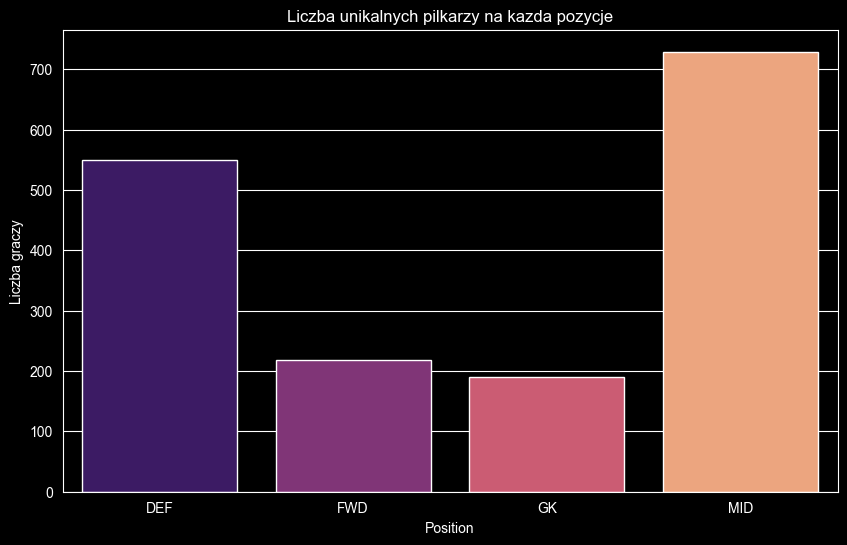

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(data=data.groupby("position")["name"].nunique(), palette="magma", legend=False)
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [21]:
[c for c in data.columns if "points" in c]

['total_points']

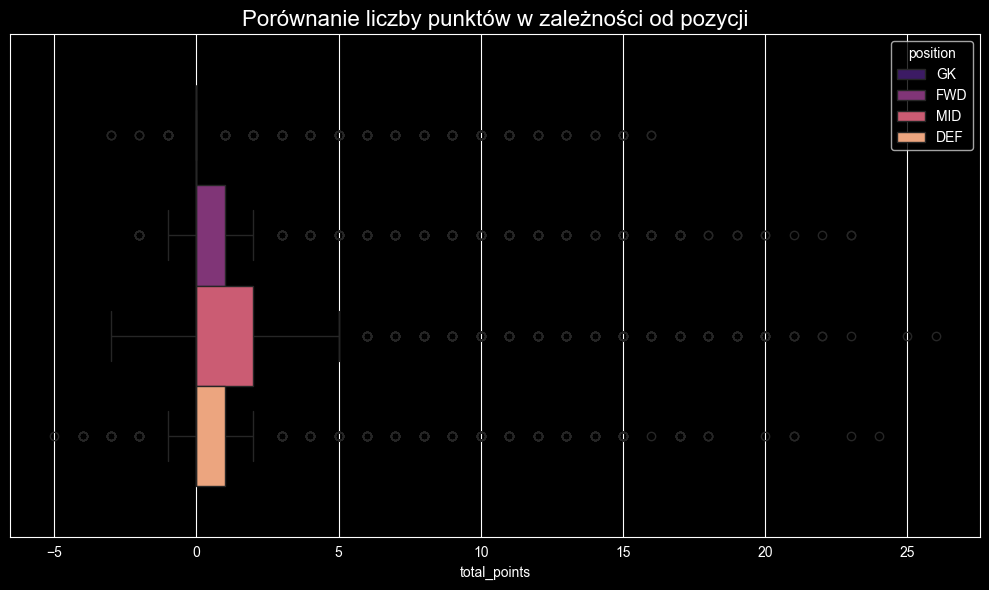

In [22]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position", palette="magma")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Skośność: 3.112
Kurtoza:    11.848
Udział zer:          61.6%


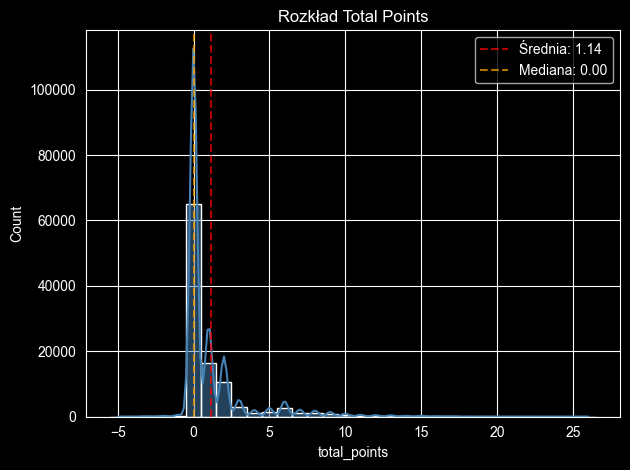

In [23]:
ax = sns.histplot(data.total_points, kde=True, discrete=True, bins=30,
             color='steelblue')
ax.axvline(data.total_points.mean(), linestyle='--', color='r', alpha=0.7,
           label=f"Średnia: {data.total_points.mean():.2f}")
ax.axvline(data.total_points.median(), linestyle='--', color='orange', alpha=0.7,
           label=f"Mediana: {data.total_points.median():.2f}")



ax.legend(loc='upper right')
ax.set_title('Rozkład Total Points')

plt.tight_layout()

skew = float(data.total_points.skew())
kurt = float(data.total_points.kurtosis())
zero_pct = (data.total_points == 0).mean() * 100
print(f"Skośność: {skew:.3f}")
print(f"Kurtoza:    {kurt:.3f}")
print(f"Udział zer:          {zero_pct:.1f}%")

In [24]:
data.value.quantile(.5), data.value.quantile(.955)


(np.float64(4.5), np.float64(7.0))

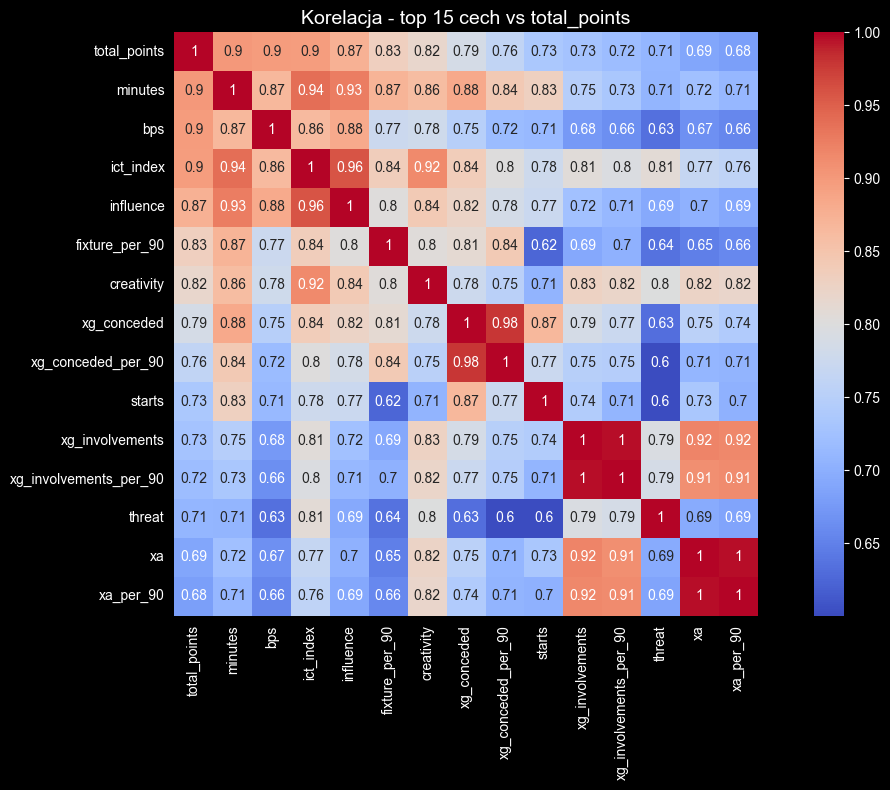

In [25]:
corr = data.select_dtypes(exclude=["object", "string"]).corr(method='spearman').apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)
plt.title("Korelacja - top 15 cech vs total_points", fontsize=14)
plt.tight_layout()

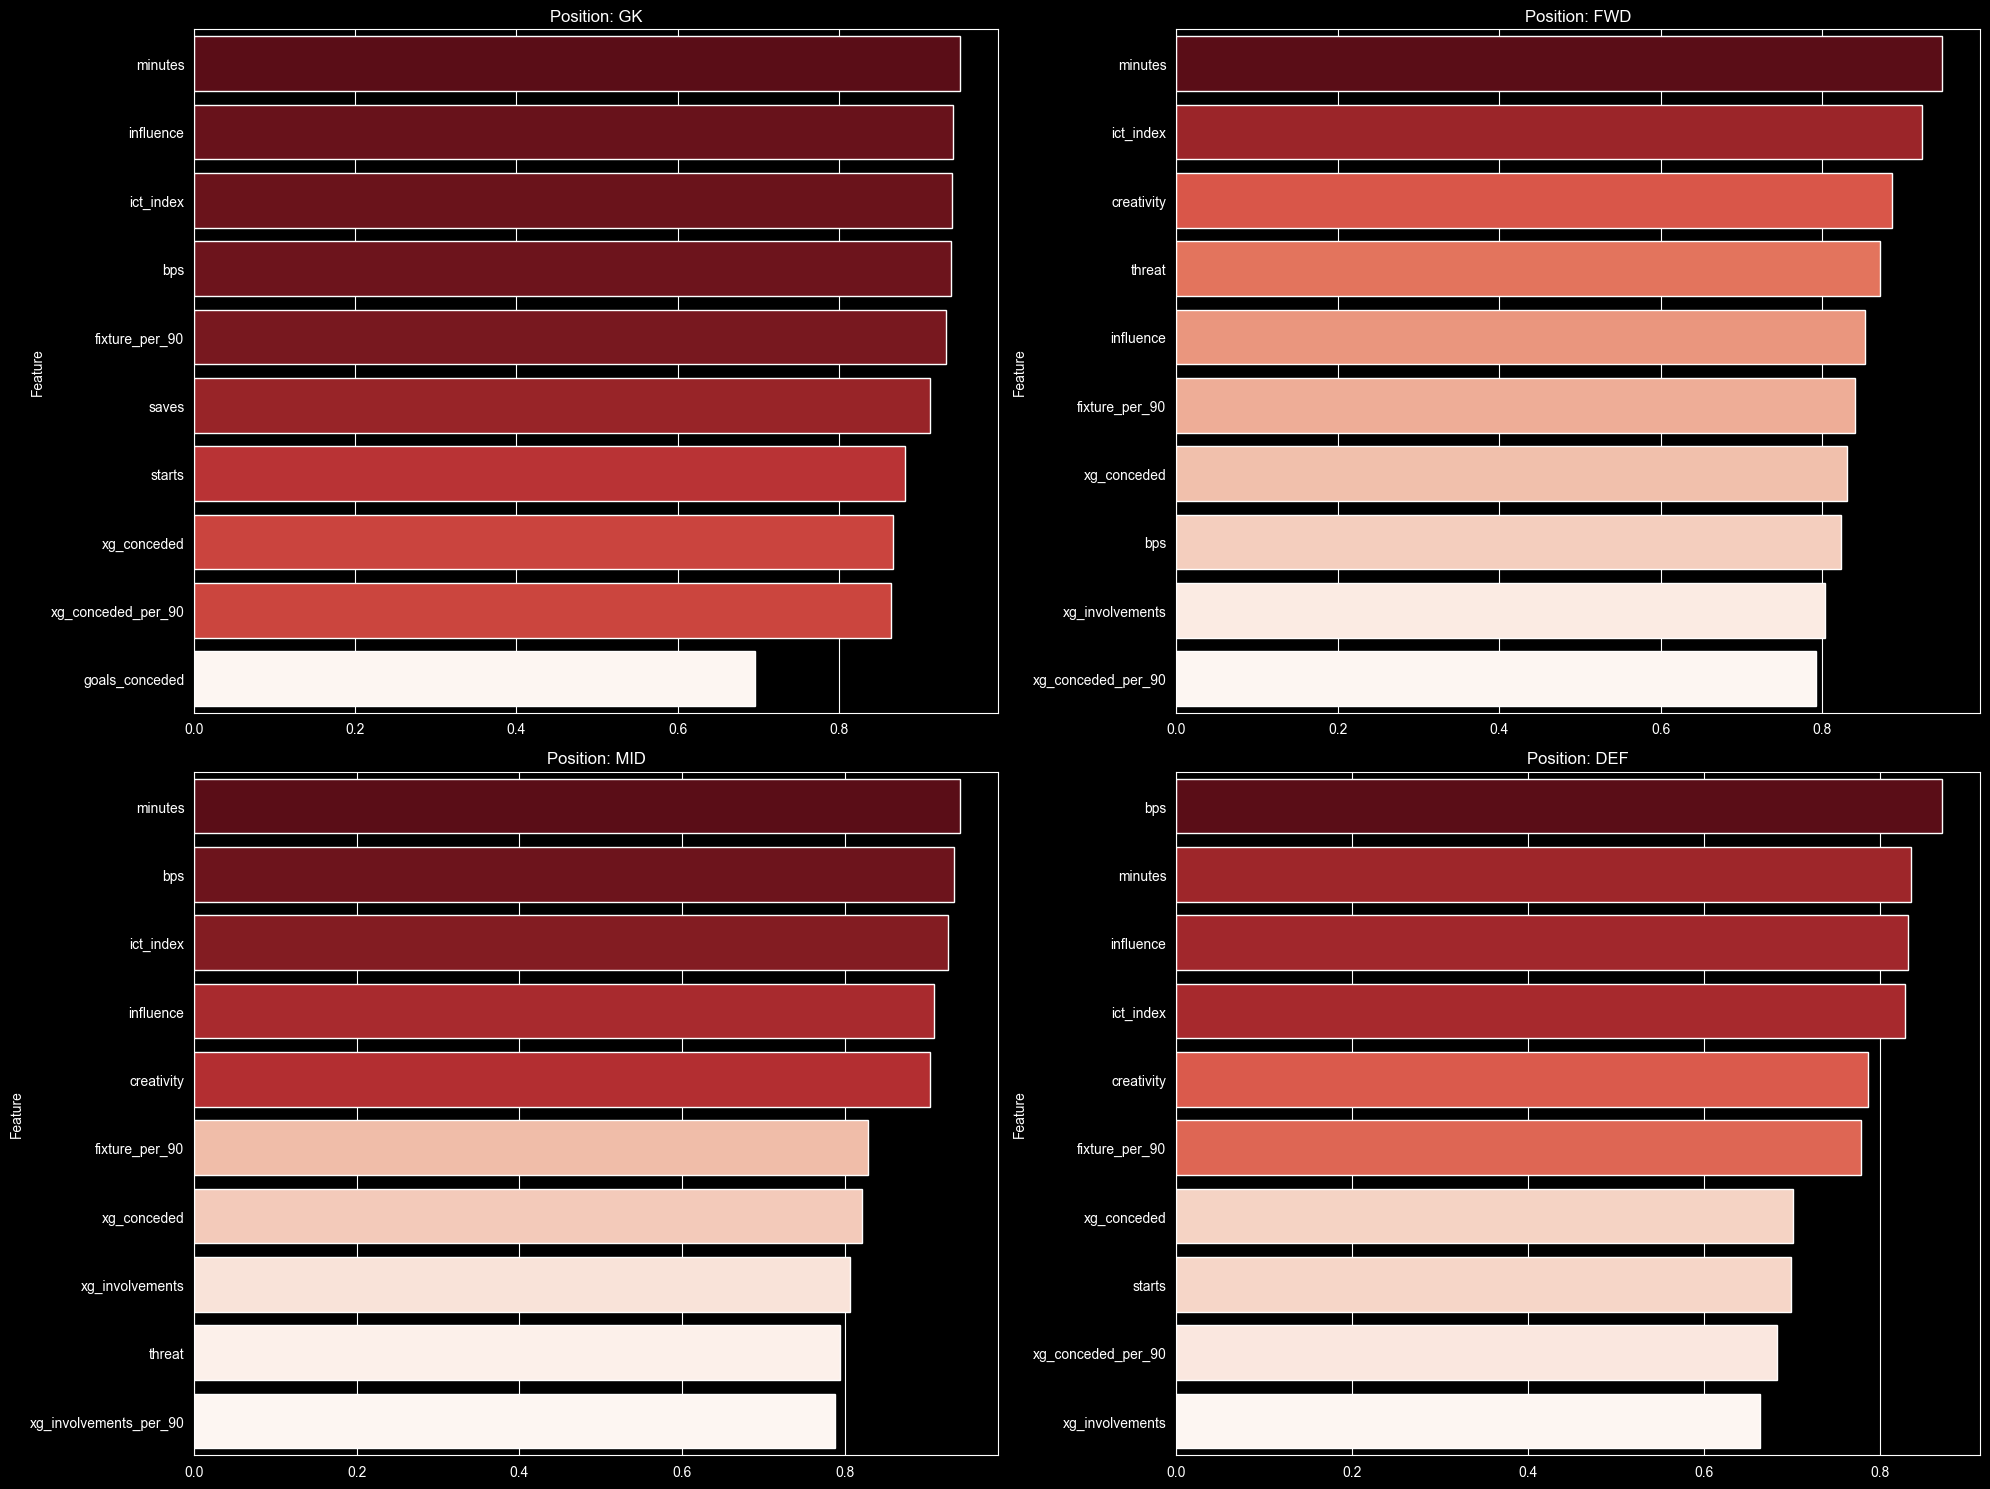

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) 
axes_flat = axes.flatten()

for idx, position in enumerate(data.position.unique()):
    subset = data[data.position == position].select_dtypes(exclude=["object", "string"])
    corr = subset.corr("spearman").apply(np.abs)
    
    plot_data = corr["total_points"].sort_values(ascending=False).head(11).drop(["total_points"])
    
    sns.barplot(
        x=plot_data.values,
        y=plot_data.index,
        ax=axes_flat[idx],
        hue=plot_data.values,
        palette="Reds",
        legend=False
    )
    
    axes_flat[idx].set_title(f"Position: {position}")
    axes_flat[idx].set_ylabel("Feature")

plt.tight_layout()

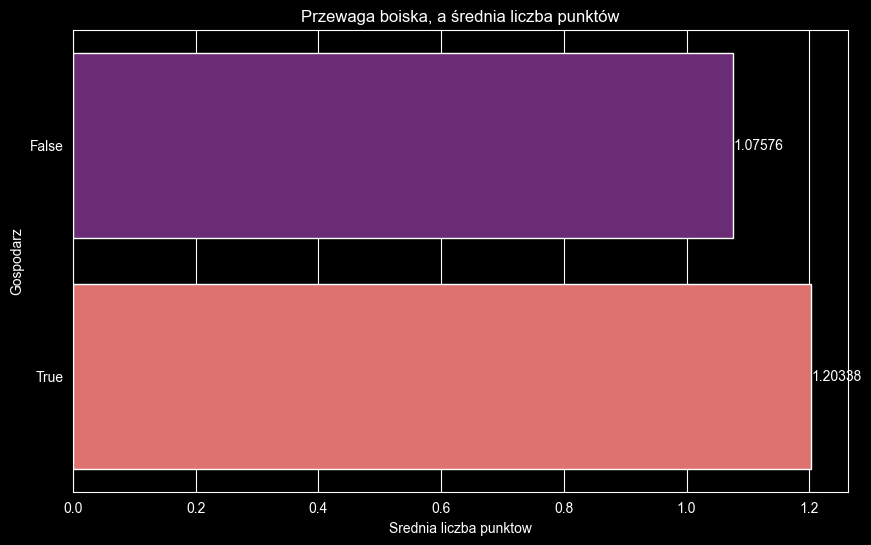

In [27]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    palette="magma",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [28]:
curr_gw = data[data.season==data.season.max()].gw.max()

In [29]:
"""fig = px.scatter(
    data[(data.season == data.season.max()) & (data.gw==curr_gw)],
    x="selected",
    y="total_points",
    color="position",
    facet_col="position",
    facet_col_wrap=2,
    hover_name="name", 
    hover_data={"selected": True, "total_points": True, "position": False},
    color_discrete_sequence=px.colors.sequential.Plasma,
    opacity=0.7,
    height=850,
    title="Punkty piłkarzy według pozycji i popularności"
)

fig.for_each_xaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d", 
    tickangle=0,
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    
))

fig.for_each_yaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d",
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    title_text="Suma punktów"
))

fig.update_layout(
    showlegend=False,
    template="plotly_dark",
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="#FFFFFF"
    ),    
    )


for annotation in fig["layout"]["annotations"]:
    annotation['font'] = dict(size=14, color="#FFFFFF", family="Arial Black")
    annotation['text'] = annotation['text'].split("=")[-1].upper()

fig.show(renderer="notebook")"""

'fig = px.scatter(\n    data[(data.season == data.season.max()) & (data.gw==curr_gw)],\n    x="selected",\n    y="total_points",\n    color="position",\n    facet_col="position",\n    facet_col_wrap=2,\n    hover_name="name", \n    hover_data={"selected": True, "total_points": True, "position": False},\n    color_discrete_sequence=px.colors.sequential.Plasma,\n    opacity=0.7,\n    height=850,\n    title="Punkty piłkarzy według pozycji i popularności"\n)\n\nfig.for_each_xaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d", \n    tickangle=0,\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n\n))\n\nfig.for_each_yaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d",\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n    title_text="Suma punktów"\n))\n\nfig.update_layout(\n    showlegend=False,\n    template="plotly_dark",\n    font=dict(\n        family="Arial, sans-serif",\n        size=12,\n        col

In [30]:
data[(data.season==data.season.max()) & (data.gw==curr_gw)].loc[
    (data.selected < data.selected.quantile(.5)) &
    (data.total_points > data.total_points.quantile(.9)) &
    (data.minutes > 0),
["name", "position", "selected", "total_points", "xP", "gw", "minutes"]].sort_values(by=["position", "total_points"], ascending=False)

,name,position,selected,total_points,xP,gw,minutes
89971,André Trindade da Costa Neto,MID,0.000049,12.0,3.4,29.0,90.0
54435,Douglas Luiz Soares de Paulo,MID,0.000060,7.0,2.7,29.0,62.0
97159,Habib Diarra,MID,0.000056,7.0,4.0,29.0,90.0
46954,Leon Bailey,MID,0.000065,5.0,1.5,29.0,62.0
65270,Dwight McNeil,MID,0.000101,5.0,4.2,29.0,86.0
97526,Archie Gray,MID,0.000098,5.0,3.7,29.0,90.0
42219,Sander Berge,MID,0.000052,4.0,3.0,29.0,81.0
42438,Mathias Jensen,MID,0.000064,4.0,2.2,29.0,90.0
77859,Mats Wieffer,MID,0.000078,4.0,0.8,29.0,76.0
92031,Melker Ellborg,GK,0.000004,10.0,2.5,29.0,90.0


In [31]:
team_x_stats = [c for c in data.columns if "x" in c and c!="ict_index" and ("team" in c or "opp" in c)]
player_x_stasts = [c for c in data.columns if "x" in c and c!="ict_index" and c not in team_x_stats and c !="xP"]

player_x_stasts

['xa',
 'xg_involvements',
 'xg',
 'xg_conceded',
 'fixture',
 'xa_per_90',
 'xg_involvements_per_90',
 'xg_per_90',
 'xg_conceded_per_90',
 'fixture_per_90']

In [32]:
data.position.unique()

array(['GK', 'FWD', 'MID', 'DEF'], dtype=object)

In [33]:
"""radar_plot_x_stats(df=data,
                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],\n                   stats=player_x_stasts)'

In [34]:
"""radar_plot_x_stats(df=data,
                   players=['Kenny Tete', "Marc Guéhi", "Lewis Hall",  'Trevoh Chalobah'],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=[\'Kenny Tete\', "Marc Guéhi", "Lewis Hall",  \'Trevoh Chalobah\'],\n                   stats=player_x_stasts)'

In [35]:
pca_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("pca", PCA())
])

umap_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("umap", umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.001, random_state=77))
])

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [37]:
X = data.select_dtypes(exclude="object").drop(columns=["gw", "round", "code", "element", "season"])


In [38]:
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [39]:
pca1 = pca_pipe.fit_transform(X)


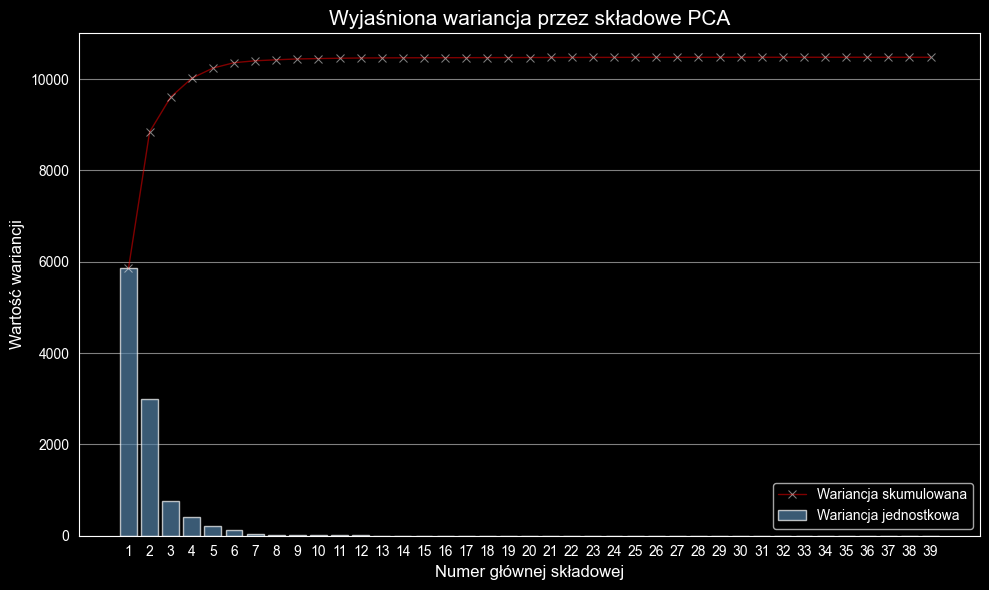

In [40]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1)), y=pca_pipe.named_steps["pca"].explained_variance_, color="steelblue", alpha=0.7, label="Wariancja jednostkowa")

sns.lineplot(x=range(len(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1))), y=np.cumsum(pca_pipe.named_steps["pca"].explained_variance_), color="red", marker="x", linewidth=1, alpha=.5, label="Wariancja skumulowana")

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title("Wyjaśniona wariancja przez składowe PCA", fontsize=15)
plt.xlabel("Numer głównej składowej", fontsize=12)
plt.ylabel("Wartość wariancji", fontsize=12)
plt.legend()

plt.grid(axis="y", alpha=.5)
plt.tight_layout()

In [41]:
pca_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(2))
])

pca2 = pca_pipe.fit_transform(X)


Text(0.5, 1.0, 'Wpływ cech na główne składowe')

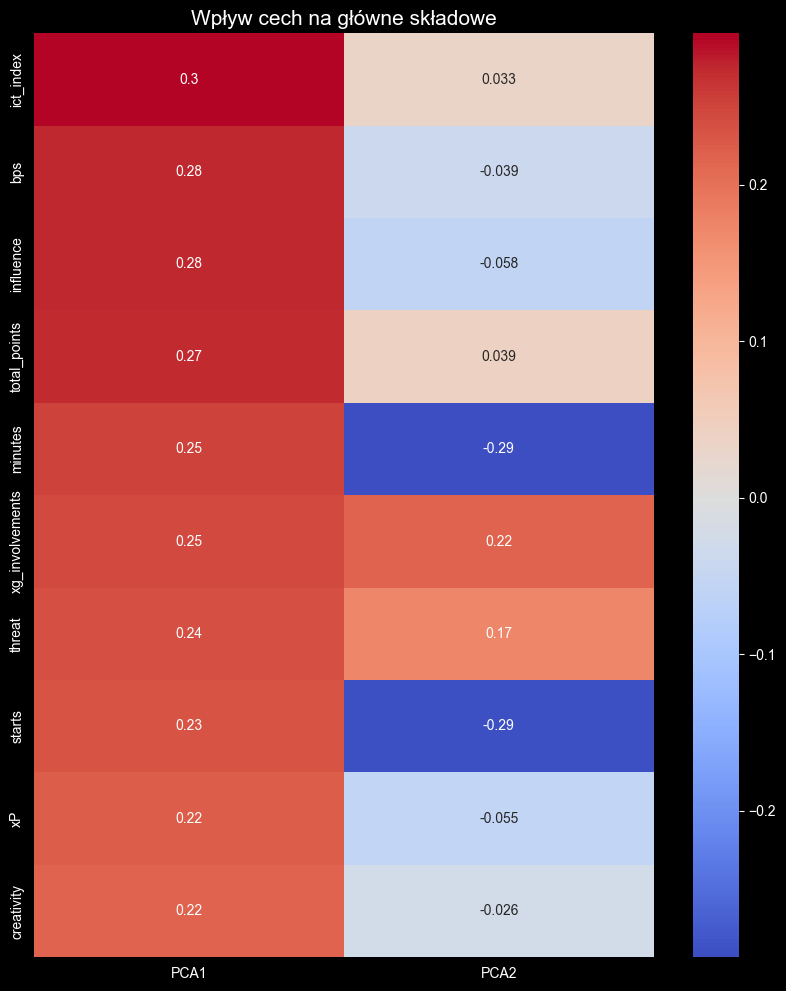

In [42]:
loadings = pd.DataFrame(
    pca_pipe.named_steps["pca"].components_[:2].T, 
    columns=['PCA1', 'PCA2'], 
    index=X.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings.sort_values(by=["PCA1", "PCA2"], ascending=False).head(10), 
            annot=True, cmap='coolwarm', center=0)

plt.title("Wpływ cech na główne składowe", fontsize=15)

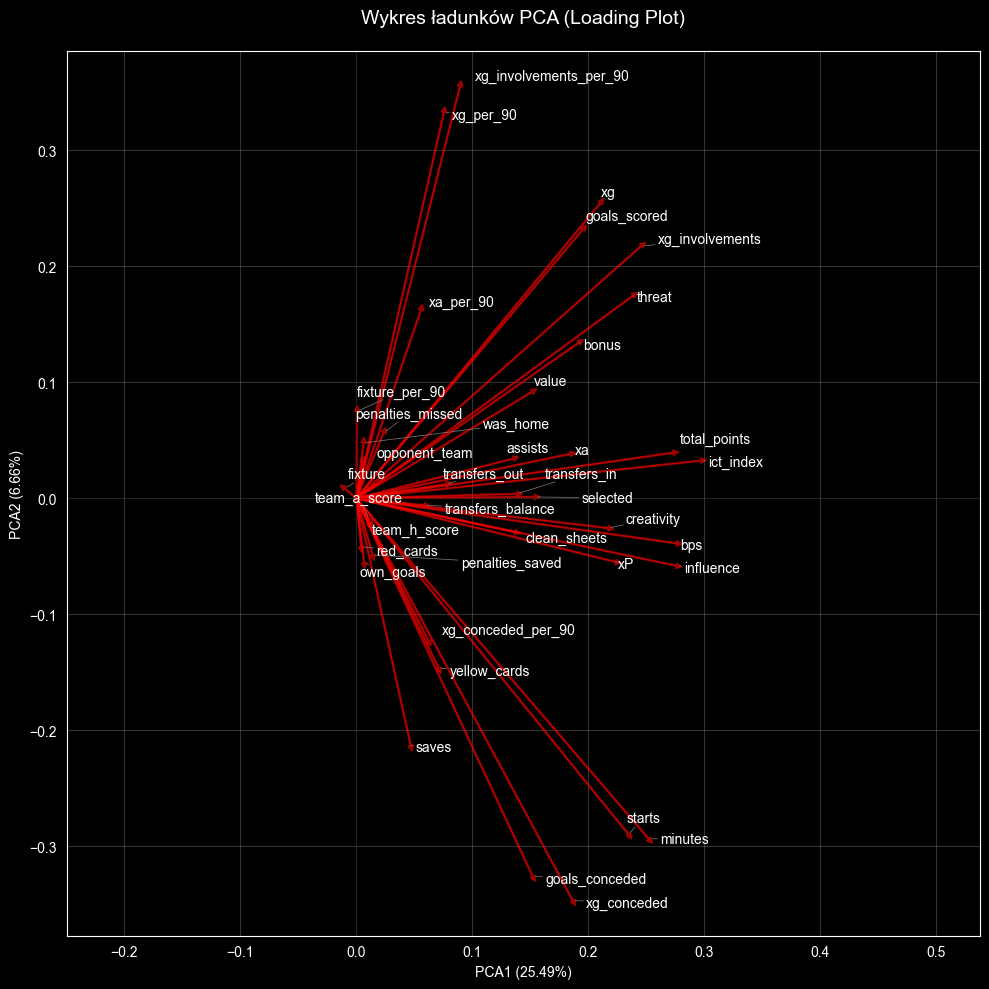

In [43]:
def plot_pca_loadings(loadings, pca_obj):
    plt.figure(figsize=(10, 10))
    
    texts = []
    for i, feature in enumerate(loadings.index):
        x = loadings.iloc[i, 0]
        y = loadings.iloc[i, 1]
        
        plt.arrow(0, 0, x, y, color='red', alpha=0.5, head_width=0.005, head_length=0.005)
        
        texts.append(plt.text(x, y, feature, fontsize=10, fontweight='medium'))

    circle = plt.Circle((0,0), 1, color='navy', fill=False, linestyle='--', alpha=0.2)
    plt.gca().add_artist(circle)

    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.axis('equal')
    
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    
    plt.xlabel(f'PCA1 ({pca_obj.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA2 ({pca_obj.explained_variance_ratio_[1]:.2%})')
    
    plt.title('Wykres ładunków PCA (Loading Plot)', fontsize=14, pad=20)
    plt.grid(alpha=0.2)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()

plot_pca_loadings(loadings, pca_pipe.named_steps["pca"])

In [44]:
from sklearn.metrics import silhouette_score

In [58]:
def cluster_and_test(data, k_map, season:int | list[int] =None, test_features=None, num_drop=None):

    if test_features is None:
        test_features = ['total_points', 'minutes', 'xg_per_90', 'xa_per_90',
                         'xg_conceded_per_90', 'team_xp', 'opp_xp']
    if num_drop is None:
        num_drop = ['gw', 'round', 'code', 'element', 'season', 'id',
                    'total_points', 'minutes']
    if isinstance(season, int):
        df = data[data.season == season].copy()
    elif isinstance(season, list):
        df = data[data.season.isin(season)].copy()
    if df.empty:
        raise ValueError(f"Brak danych dla sezonu: {season}. "
                         f"Dostępne sezony: {data.season.unique()}")

    num_cols = df.select_dtypes('number').columns.drop(num_drop, errors='ignore')

    positions = [p for p in df.position.unique() if p in k_map]
    n_pos = len(positions)
    fig, axes = plt.subplots(
        (n_pos + 1) // 2, 2, figsize=(15, 6 * ((n_pos + 1) // 2))
    )
    axes = np.array(axes).flatten()
    cluster_results = {}

    for ax, pos in zip(axes, positions):
        d = df[df.position == pos].copy().reset_index(drop=True)
        X = StandardScaler().fit_transform(d[num_cols].fillna(0))
        k = k_map.get(pos, 3)

        kmeans = KMeans(n_clusters=k, n_init=20, random_state=77)
        labels = kmeans.fit_predict(X)
        d['cluster'] = labels
        sil_score = silhouette_score(X, labels)
        print(d.groupby("cluster")["total_points"].mean())
        print(f"{pos}: " f"k={k} | " f"silhouette={sil_score:.3f}")
        pca_coords = PCA(2).fit_transform(X)
        d['pca_x'], d['pca_y'] = pca_coords[:, 0], pca_coords[:, 1]

        d_plot = d.groupby(['name', 'cluster'], as_index=False)[['pca_x', 'pca_y']].mean()

        sns.scatterplot(data=d_plot, x='pca_x', y='pca_y', hue='cluster',
                        ax=ax, palette='viridis', s=50)
        txts = [ax.text(r.pca_x, r.pca_y, r['name'], fontsize=7)
                for c in range(k)
                for _, r in d_plot[d_plot.cluster == c].head(5).iterrows()]
        adjust_text(txts, ax=ax, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
        ax.set_title(f"{pos}  (k={k})")
        cluster_results[pos] = d

    for ax in axes[len(positions):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Kruskal-Wallis + Bonferroni ───────────────────────────────────────────
    rows = []
    for pos, d in cluster_results.items():
        feats = [f for f in test_features if f in d.columns]
        if not feats:
            continue

        pvals, hstats = [], []
        for feat in feats:
            groups = [d[d.cluster == c][feat].dropna().values for c in d.cluster.unique()]
            try:
                h, p = kruskal(*groups)
            except Exception:
                h, p = np.nan, 1.0
            hstats.append(h)
            pvals.append(p)

        reject, p_corr, _, _ = multipletests(pvals, method='bonferroni')
        n, k_pos = len(d), d.cluster.nunique()
        eta2 = [(h - k_pos + 1) / (n - k_pos) if not np.isnan(h) else np.nan
                for h in hstats]

        for feat, h, p, pc, sig, e2 in zip(feats, hstats, pvals, p_corr, reject, eta2):
            rows.append(dict(position=pos, feature=feat,
                             H_stat=round(h, 3) if not np.isnan(h) else np.nan,
                             p_bonferroni=round(pc, 4), significant=sig,
                             eta_squared=round(e2, 4) if not np.isnan(e2) else np.nan))

    if not rows:
        raise RuntimeError("Brak wyników Kruskala – sprawdź test_features i dane.")

    # ── Heatmapa ──────────────────────────────────────────────────────────────
    summary = pd.DataFrame(rows)
    pivot_eta = summary.pivot_table(index='feature', columns='position',
                                    values='eta_squared', aggfunc='first')
    pivot_sig = summary.pivot_table(index='feature', columns='position',
                                    values='significant', aggfunc='first')

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(pivot_eta, annot=True, fmt='.3f', cmap='YlOrRd',
                     linewidths=0.5, cbar_kws={'label': 'Eta²'})
    for i, feat in enumerate(pivot_eta.index):
        for j, pos in enumerate(pivot_eta.columns):
            val = pivot_sig.loc[feat, pos]
            if pd.notna(val) and val:
                ax.text(j + 0.85, i + 0.25, '*', fontsize=14,
                        color='navy', fontweight='bold')

    plt.title(f'Eta² per pozycja | sezon: {season} | * = istotne po Bonferronim')
    plt.tight_layout()
    plt.show()
    print("Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt")

    return summary, cluster_results

cluster
0    0.017061
1    2.000000
2    3.340010
Name: total_points, dtype: float32
GK: k=3 | silhouette=0.511
cluster
0    2.369653
1    8.197485
2    0.174357
Name: total_points, dtype: float32
MID: k=3 | silhouette=0.352
cluster
0    2.280927
1    0.091951
2    6.269046
Name: total_points, dtype: float32
DEF: k=3 | silhouette=0.334
cluster
0    2.191854
1    0.200670
2    8.557272
Name: total_points, dtype: float32
FWD: k=3 | silhouette=0.405


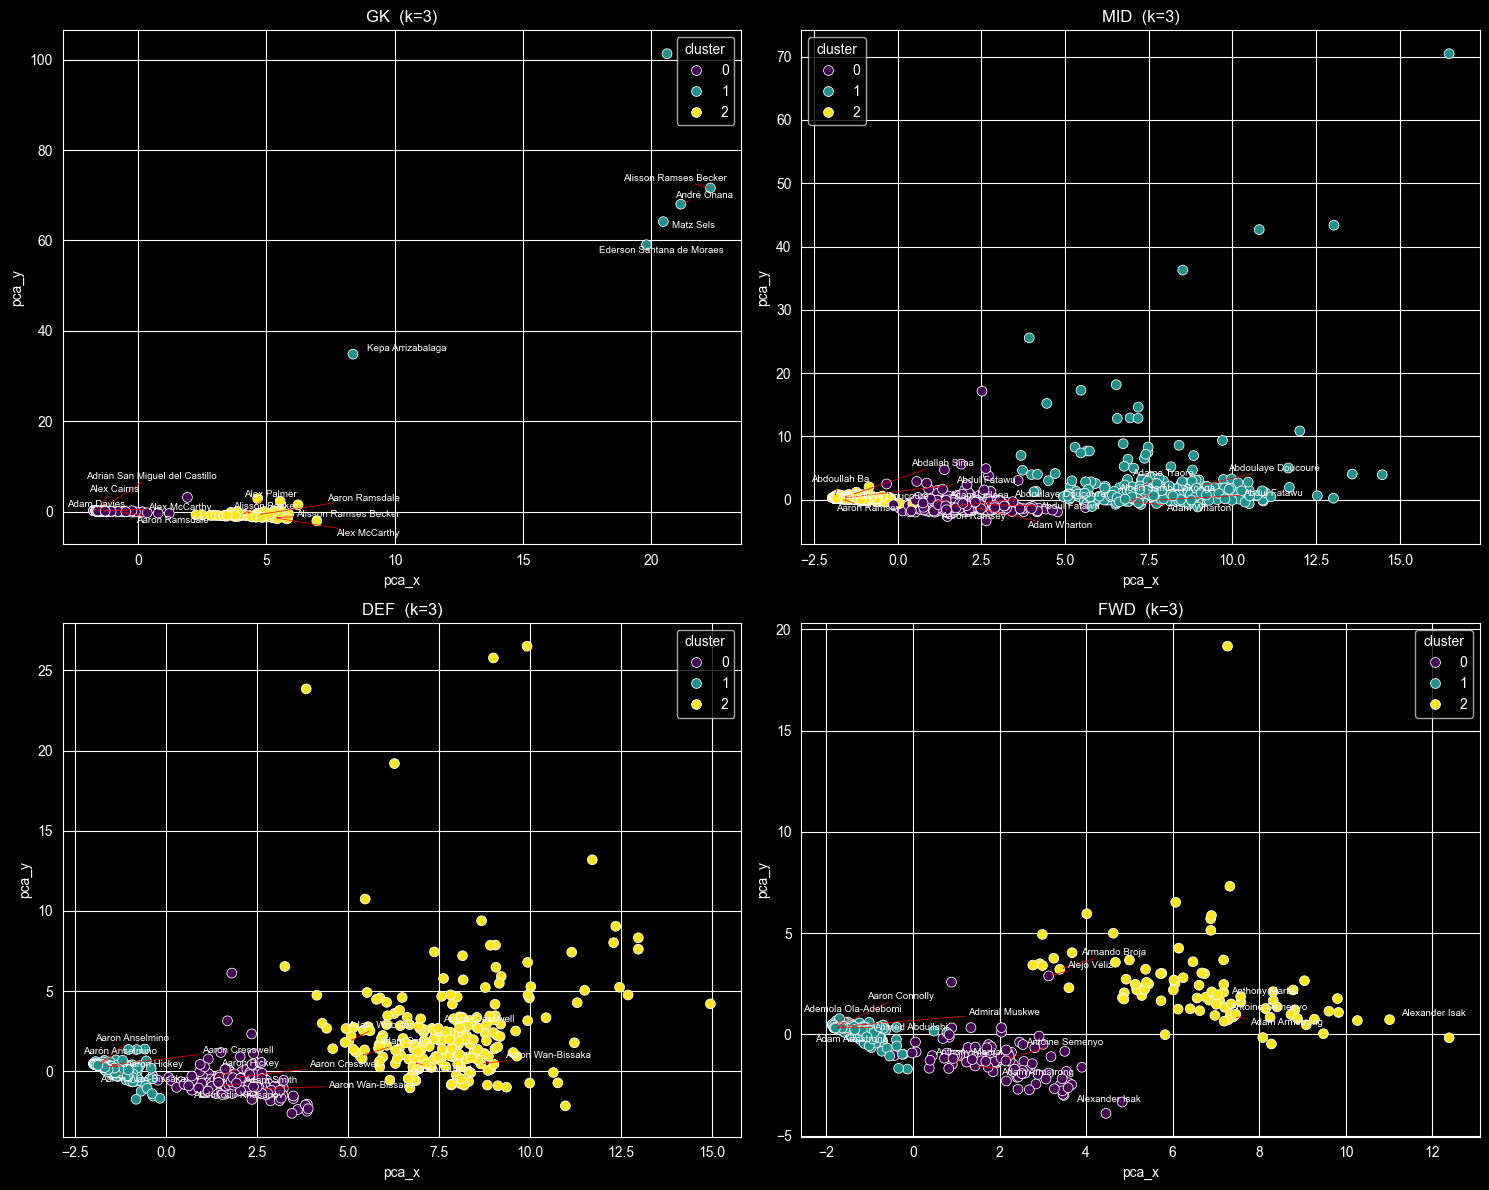

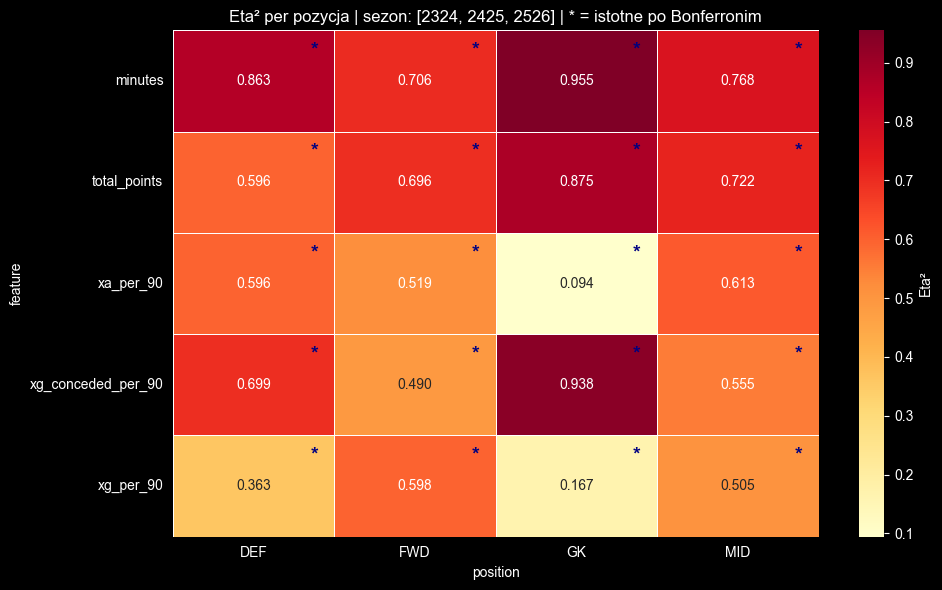

Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt


In [59]:
summary, clusters = cluster_and_test(data=data, k_map={'FWD': 3, 'MID': 3, 'DEF': 3, 'GK': 3}, season=[2324, 2425, 2526])

In [47]:
data.to_parquet(config.TIDY_DATA_PATH)